<a href="https://colab.research.google.com/github/zly554411-arch/ECON3916-Statistical-Machine-Learning/blob/main/final/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Which country-level socioeconomic, demographic, and health indicators best predict adolescent fertility rates, and what are the most influential predictors?


**This is a prediction (umbrella) problem because:** Forecasting a continuous outcome, adolescent fertility rate, from a set of country-level input features, to learn which combination of indicators best approximates the observed fertility rate across countries and years, without claiming that any feature causally drives the outcome.

**The decision this enables:** Policymakers and international development organizations ,like UNICEF, can use predictions to identify high-risk countries before fertility rates rise, enabling proactive resource allocation, for example expanding girls' education programs, maternal health services, and reproductive healthcare.

**Dataset:** World Bank World Development Indicators
- **Source:** World Bank (URL: https://data360.worldbank.org/en/indicator/WB_GS_SP_ADO_TFRT)
- **N =** 5,267
- **Features =** 25
- **Target variable =** Adolescent fertility rate (births per 1,000 women ages 15–19)
- **Access date:** Apr.15, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving adolescent_fertility_rate.csv to adolescent_fertility_rate.csv


In [3]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
df = pd.read_csv('adolescent_fertility_rate.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (6655, 24)
Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


,Country Name,Country Code,Series Name,Series Code,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Argentina,ARG,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,64.156,64.562,66.357,65.923,65.927,66.764,...,58.79,55.022,49.926,41.751,31.492,28.54,25.767,26.414,25.56,..
1,Argentina,ARG,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,99.4,99.4,94.8,97.9,95,97.1,...,98.4,93.9,99.5,99.6,98.8,..,..,..,..,..
2,Argentina,ARG,"Contraceptive prevalence, any method (% of mar...",SP.DYN.CONU.ZS,..,..,..,..,..,..,...,..,..,..,..,70.1027087175867,..,..,..,..,..
3,Argentina,ARG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,2.4,2.37,2.432,2.4,2.411,2.393,...,2.241,2.168,2.067,1.882,1.601,1.585,1.482,1.5,1.504,..
4,Argentina,ARG,"Immunization, measles (% of children ages 12-2...",SH.IMM.MEAS,97,94,96,96,95,95,...,90,90,94,86,77,86,85,80,82,..


In [4]:
# ============================================================
# Reshape from long to wide format
# ============================================================

# Step 1: Drop the nan series row
df = df.dropna(subset=['Series Name'])

# Step 2: Melt year columns into a single 'year' column
year_cols = [col for col in df.columns if 'YR' in col]

df_long = df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)

# Clean year column to just the number
df_long['year'] = df_long['year'].str.extract(r'(\d{4})').astype(int)

# Step 3: Replace '..' (World Bank missing) with NaN
df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')

# Step 4: Pivot wide — each indicator becomes a column
df_wide = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'year'],
    columns='Series Name',
    values='value'
).reset_index()

# Flatten column names
df_wide.columns.name = None

print(df_wide.shape)
df_wide.head()

(5267, 28)


,Country Name,Country Code,year,"Adolescent fertility rate (births per 1,000 women ages 15-19)",Births attended by skilled health staff (% of total),"Contraceptive prevalence, any method (% of married women ages 15-49)",Current health expenditure (% of GDP),"Fertility rate, total (births per woman)",GDP per capita (constant 2015 US$),"Government expenditure on education, total (% of GDP)",...,"Population, total",Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Poverty headcount ratio at national poverty lines (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)","School enrollment, primary (% gross)","School enrollment, primary and secondary (gross), gender parity index (GPI)","School enrollment, secondary (% gross)","School enrollment, secondary, female (% gross)",Urban population (% of total population)
0,Afghanistan,AFG,2006,121.635,18.9,18.6,10.622766,6.686,367.758312,NaN,...,25424094.0,NaN,NaN,0.1,NaN,102.284866,0.57323,29.523890,15.328300,20.110453
1,Afghanistan,AFG,2007,117.754,NaN,NaN,9.904675,6.508,410.757729,NaN,...,25909852.0,NaN,33.7,0.1,NaN,99.322899,0.56720,28.815491,15.351360,20.590658
2,Afghanistan,AFG,2008,118.979,24.0,22.8,10.256495,6.392,417.647283,NaN,...,26482622.0,NaN,NaN,0.1,NaN,104.445137,0.58602,38.930851,22.788450,21.124148
3,Afghanistan,AFG,2009,109.655,NaN,NaN,9.818487,6.295,488.830652,NaN,...,27466101.0,NaN,NaN,0.1,NaN,99.705421,0.60961,44.299950,28.317579,21.688548
4,Afghanistan,AFG,2010,105.648,34.3,21.8,8.569672,6.195,542.871030,3.47945,...,28284089.0,NaN,NaN,0.1,NaN,103.485603,0.62581,50.440620,33.026241,22.261480


### 2.2 Basic Description

In [5]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df_wide.info()
df_wide.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5267 entries, 0 to 5266
Data columns (total 28 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Country Name                                                                                       5267 non-null   object 
 1   Country Code                                                                                       5267 non-null   object 
 2   year                                                                                               5267 non-null   int64  
 3   Adolescent fertility rate (births per 1,000 women ages 15-19)                                      5035 non-null   float64
 4   Births attended by skilled health staff (% of total)                                               1674 non-null   float

,year,"Adolescent fertility rate (births per 1,000 women ages 15-19)",Births attended by skilled health staff (% of total),"Contraceptive prevalence, any method (% of married women ages 15-49)",Current health expenditure (% of GDP),"Fertility rate, total (births per woman)",GDP per capita (constant 2015 US$),"Government expenditure on education, total (% of GDP)","Immunization, measles (% of children ages 12-23 months)","Labor force participation rate, female (% of female population ages 15-64) (modeled ILO estimate)",...,"Population, total",Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Poverty headcount ratio at national poverty lines (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)","School enrollment, primary (% gross)","School enrollment, primary and secondary (gross), gender parity index (GPI)","School enrollment, secondary (% gross)","School enrollment, secondary, female (% gross)",Urban population (% of total population)
count,5267.000000,5035.000000,1674.000000,611.000000,4314.000000,5035.000000,4853.000000,3425.000000,4573.000000,4686.000000,...,5.035000e+03,1731.000000,953.000000,3370.000000,3427.000000,4029.000000,2737.000000,3624.000000,3585.000000,5035.000000
mean,2015.440478,48.769549,90.512158,47.528993,6.374119,2.726936,15175.498431,4.274576,86.011119,56.050480,...,2.997299e+08,9.329058,21.839454,1.703981,89.528463,101.719390,0.979623,83.006163,83.249965,59.117620
std,5.735466,40.176468,17.233906,21.718104,2.900168,1.372512,22252.837841,1.793609,13.286576,16.744025,...,9.318499e+08,15.939464,12.131948,3.855219,16.061166,11.820371,0.067766,26.651371,28.138901,22.745921
min,2006.000000,0.465000,9.400000,3.500000,1.233332,0.582000,252.582020,0.000004,18.000000,4.847000,...,9.646000e+03,0.000000,0.000000,0.100000,22.793760,20.915550,0.537100,3.347850,2.758470,9.464629
25%,2010.000000,15.378682,91.782987,28.162543,4.312731,1.670000,1957.517853,3.130580,80.000000,48.867500,...,1.607626e+06,0.400000,13.600000,0.100000,82.709894,97.137199,0.969980,66.948084,67.493698,40.446967
50%,2015.000000,38.710000,98.700000,50.800000,5.643427,2.227000,5891.420694,4.083440,91.000000,58.489789,...,1.009312e+07,1.600000,20.000000,0.400000,95.376182,101.104393,0.995970,89.181916,90.547523,59.238537
75%,2020.000000,72.798500,99.800000,65.632849,8.053393,3.531722,18918.826346,5.078640,96.000000,67.600670,...,6.141253e+07,10.300000,25.900000,1.500000,99.169060,105.912109,1.013970,101.203674,101.290989,77.562104
max,2025.000000,204.311000,100.000000,86.300000,27.089685,7.744000,247170.219911,16.390530,99.000000,88.523000,...,8.141809e+09,85.300000,82.300000,29.400000,156.167176,183.989440,1.175880,164.079819,174.837173,100.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Contraceptive prevalence, any method (% of married women ages 15-49)                                 88.4
Poverty headcount ratio at national poverty lines (% of population)                                  81.9
Literacy rate, adult female (% of females ages 15 and above)                                         71.2
Births attended by skilled health staff (% of total)                                                 68.2
Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)                                  67.1
School enrollment, primary and secondary (gross), gender parity index (GPI)                          48.0
Prevalence of HIV, total (% of population ages 15-49)                                                36.0
Government expenditure on education, total (% of GDP)                                                35.0
Primary completion rate, total (% of relevant age group)                                             34.9
School enrollment,

/tmp/ipykernel_3854/837023248.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


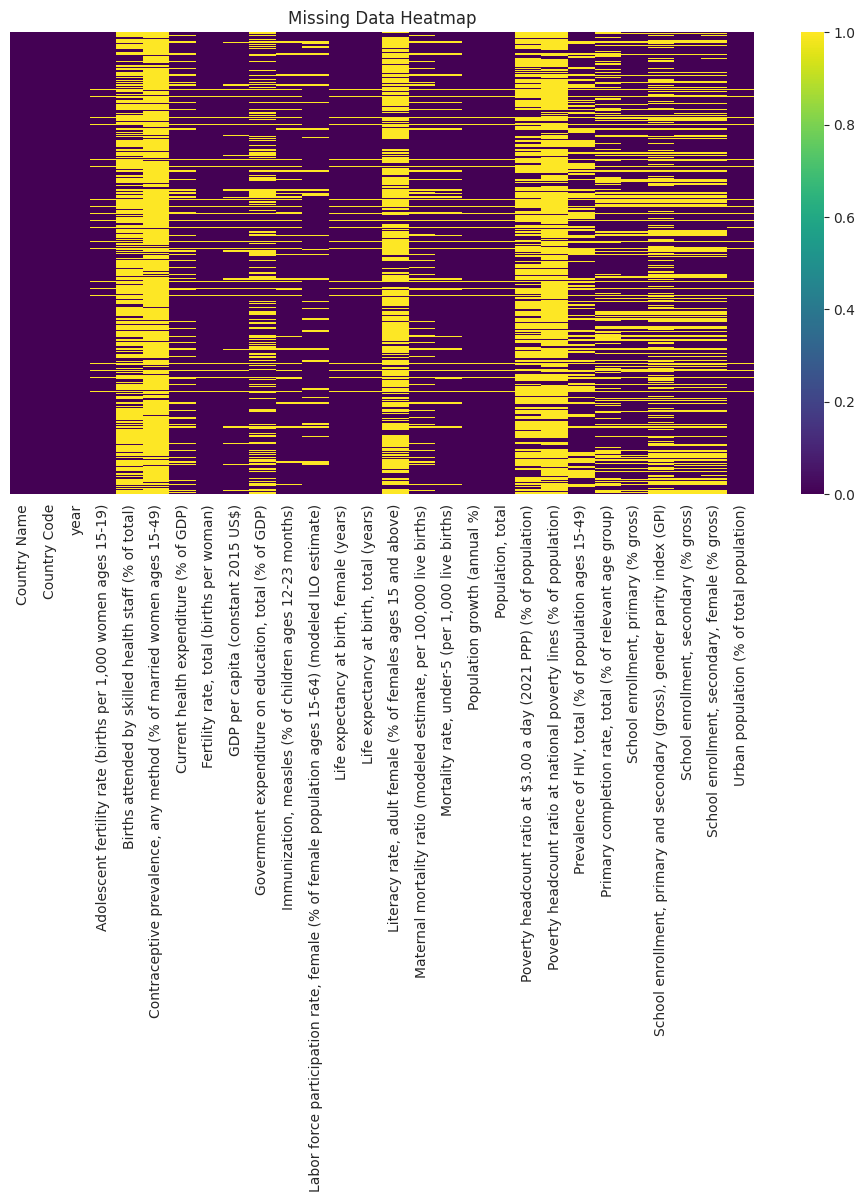

In [6]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df_wide.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0].round(3) * 100)

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_wide.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** MAR
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

In [7]:
# ============================================================
# Drop high-missing columns (>60%)
# ============================================================
cols_to_drop = missing_pct[missing_pct > 0.60].index.tolist()
df_clean = df_wide.drop(columns=cols_to_drop)
print('Dropped:', cols_to_drop)

# Drop rows where target variable is missing
df_clean = df_clean.dropna(subset=['Adolescent fertility rate (births per 1,000 women ages 15-19)'])

# Impute remaining missing values with median (per country)
numeric_cols = df_clean.select_dtypes(include='number').columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print('Shape after cleaning:', df_clean.shape)
df_clean.isnull().sum().sum()

Dropped: ['Contraceptive prevalence, any method (% of married women ages 15-49)', 'Poverty headcount ratio at national poverty lines (% of population)', 'Literacy rate, adult female (% of females ages 15 and above)', 'Births attended by skilled health staff (% of total)', 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)']
Shape after cleaning: (5035, 23)


np.int64(0)

In [8]:
# ============================================================
# Rename columns to short names
# ============================================================

short_names = {
    'Adolescent fertility rate (births per 1,000 women ages 15-19)': 'adolescent_fertility',
    'Current health expenditure (% of GDP)': 'health_expenditure',
    'Fertility rate, total (births per woman)': 'total_fertility_rate',
    'GDP per capita (constant 2015 US$)': 'gdp_per_capita',
    'Government expenditure on education, total (% of GDP)': 'education_expenditure',
    'Immunization, measles (% of children ages 12-23 months)': 'measles_immunization',
    'Labor force participation rate, female (% of female population ages 15-64) (modeled ILO estimate)': 'female_labor_force',
    'Life expectancy at birth, female (years)': 'female_life_expectancy',
    'Life expectancy at birth, total (years)': 'life_expectancy',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births)': 'maternal_mortality',
    'Mortality rate, under-5 (per 1,000 live births)': 'under5_mortality',
    'Population growth (annual %)': 'population_growth',
    'Population, total': 'population',
    'Prevalence of HIV, total (% of population ages 15-49)': 'hiv_prevalence',
    'Primary completion rate, total (% of relevant age group)': 'primary_completion',
    'School enrollment, primary (% gross)': 'primary_enrollment',
    'School enrollment, primary and secondary (gross), gender parity index (GPI)': 'gender_parity_index',
    'School enrollment, secondary (% gross)': 'secondary_enrollment',
    'School enrollment, secondary, female (% gross)': 'female_secondary_enrollment',
    'Urban population (% of total population)': 'urbanization',
}

df_clean = df_clean.rename(columns=short_names)
print(df_clean.columns.tolist())

['Country Name', 'Country Code', 'year', 'adolescent_fertility', 'health_expenditure', 'total_fertility_rate', 'gdp_per_capita', 'education_expenditure', 'measles_immunization', 'female_labor_force', 'female_life_expectancy', 'life_expectancy', 'maternal_mortality', 'under5_mortality', 'population_growth', 'population', 'hiv_prevalence', 'primary_completion', 'primary_enrollment', 'gender_parity_index', 'secondary_enrollment', 'female_secondary_enrollment', 'urbanization']


### 2.4 Distribution Plots

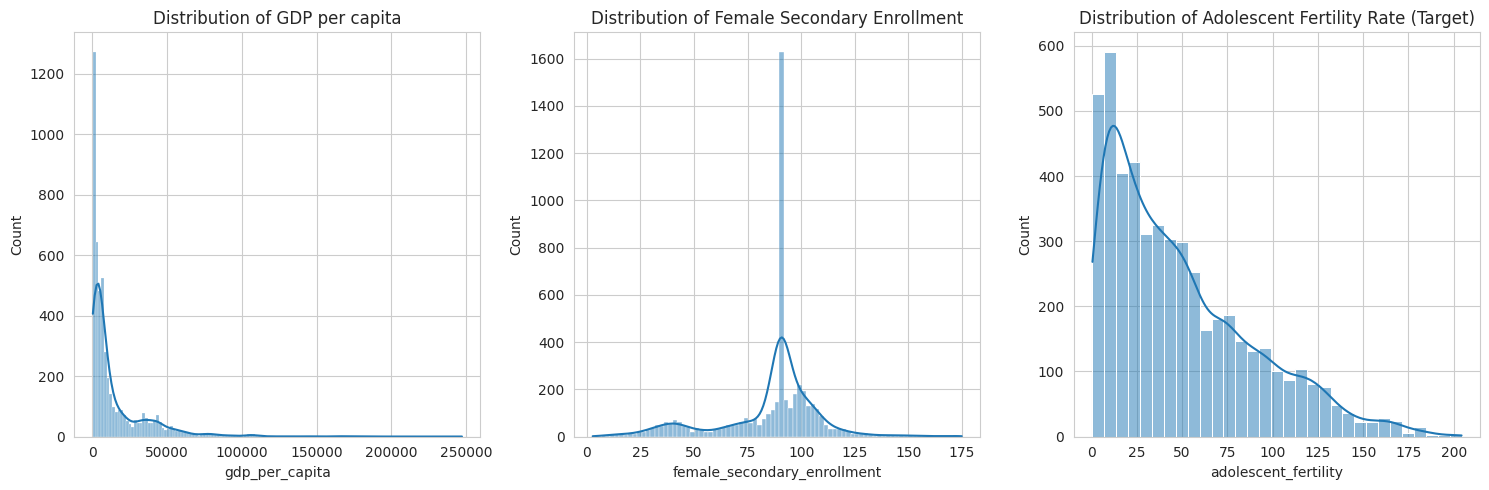

In [9]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_clean['gdp_per_capita'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of GDP per capita')

sns.histplot(df_clean['female_secondary_enrollment'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Female Secondary Enrollment')

sns.histplot(df_clean['adolescent_fertility'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Adolescent Fertility Rate (Target)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [10]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Example: check outliers in a numeric column
for col in ['gdp_per_capita',
            'female_secondary_enrollment',
            'adolescent_fertility']:
    lower, upper = tukey_fences(df_clean[col])
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.1f}%)')

gdp_per_capita: 545 outliers (10.8%)
female_secondary_enrollment: 797 outliers (15.8%)
adolescent_fertility: 79 outliers (1.6%)


**Outlier strategy:** Winsorize
(Trim? Winsorize? Keep with justification?)
Outliers are real country observations rather than data errors. I will Winsorize at the 1st and 99th percentile to reduce their influence on the model without discarding valid data.

In [11]:
# ============================================================
# Winsorize outliers at 1st and 99th percentile
# ============================================================
from scipy.stats import mstats

cols_to_winsorize = ['gdp_per_capita',
            'female_secondary_enrollment',
            'adolescent_fertility']

for col in cols_to_winsorize:
    df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

print('Winsorizing complete.')

Winsorizing complete.


### 2.6 Correlations

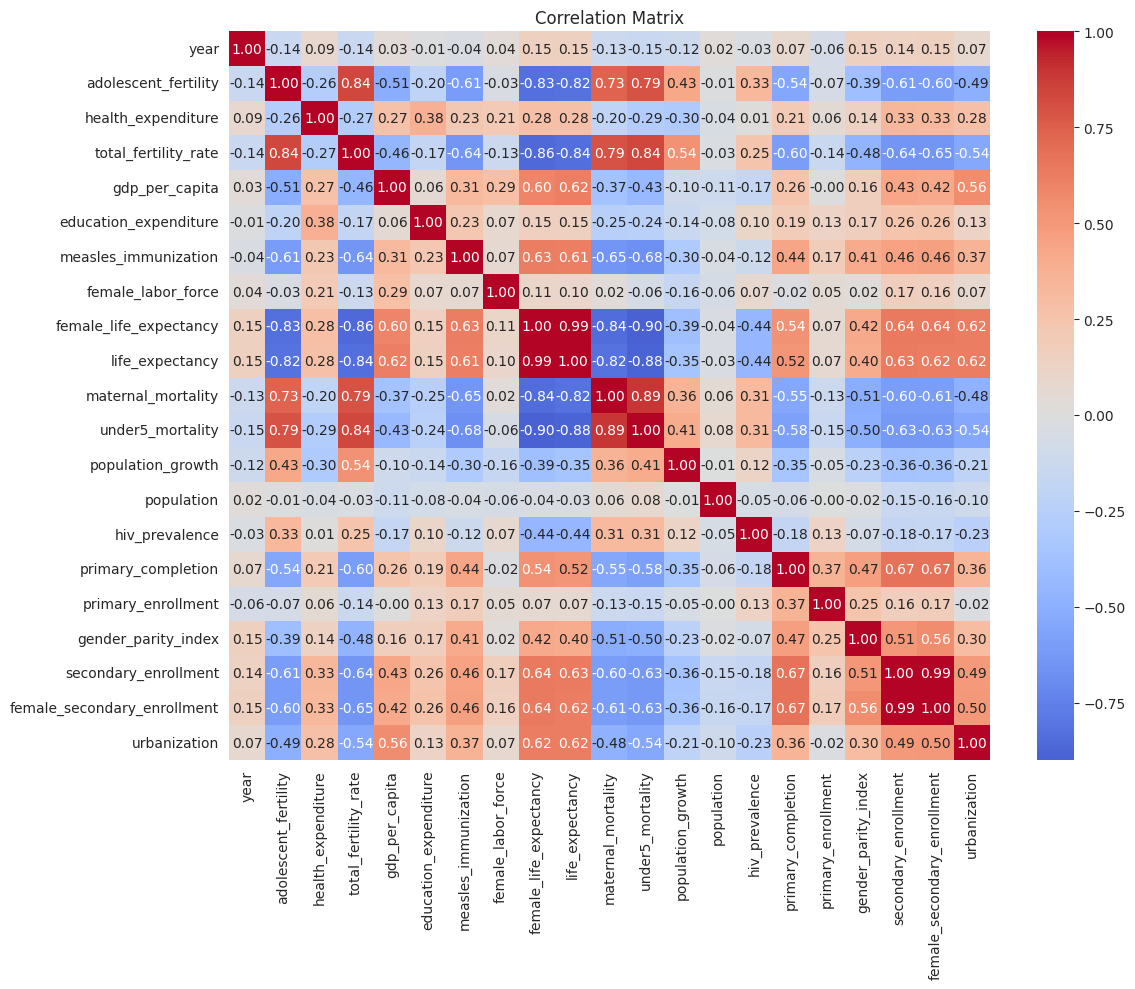

In [12]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable (adolescent fertility rate) is
   right-skewed, indicating that most countries clustered at low-to-moderate rates and a long tail of high-fertility countries. This is a regression problem, and I will apply a log transformation to the target variabl to address the skew, which will make the distribution more symmetric and improve model performance.


2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The strongest predictors of adolescent fertility rate are total fertility rate (-0.84), female/total life expectancy (-0.83/-0.82), maternal mortality (0.83), under-5 mortality (0.82), and female secondary enrollment (-0.61).

   female_life_expectancy and life_expectancy (0.99), and
   secondary_enrollment and female_secondary_enrollment (0.99) show high multicollinearity. I will drop one before modeling to reduce redundancy.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest issue was high rates of missing data, ranging from 4.4% to 88.4% across columns. Five columns exceeded 60% missingness and were dropped entirely. The remaining missing values were imputed using column medians. The missingness pattern is MAR, as
   data gaps are systematically more common in lower-income countries with
   weaker statistical infrastructure.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 5,267** observations and **M = 25** features.
After cleaning, the dataset has **N = 5,035** observations and **M = 20** features.

**Missing data:** 4.4% to 88.4%% of cells are missing. The missingness pattern appears to be MAR because missingness is systematically higher in lower-income and developing countries where data collection infrastructure is weaker. It is related to observable country characteristics, like GDP and region, rather than being purely random or dependent on the missing value itself. I will handle missing data by (1)Dropping columns with >60% missing; (2) Imputing remaining missing values with the column median, which is robust to outliers and appropriate for skewed socioeconomic indicators;(3) Dropping rows where the target variable (adolescent fertility rate) is missing.

**Outliers:** I identified 3 outliers using Tukey Fences. I will handle them by Winsorize.

**Target variable:** The target variable (adolescent fertility rate) is
right-skewed, indicating that most countries clustered at low-to-moderate rates and a long tail of high-fertility countries.

**Key finding from EDA:**

(1) Target variable is right-skewed;

(2) One feature, female secondary enrollment shows a strong negative correlation (-0.61), confirming that girls' access to education is a key protective factor against adolescent pregnancy;

(3) Another feature, GDP per capita is a moderate predictor. The correlation is -0.51, indicating wealthier countries tend to have lower adolescent fertility, but it's not the strongest signal;

(4) High multicollinearity is between female_life_expectancy and life_expectancy (0.99), and secondary_enrollment and female_secondary_enrollment (0.99);

(5) The biggest issue was high rates of missing data, ranging from 4.4% to 88.4% across columns.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [13]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Drop near-duplicates, leakage risk, and ID columns
cols_to_drop = [
    'life_expectancy',           # duplicates female_life_expectancy (0.99)
    'secondary_enrollment',      # duplicates female_secondary_enrollment (0.99)
    'total_fertility_rate',      # too directly related to target (leakage risk)
    'Country Name',
    'Country Code',
    'year'
]

df_model = df_clean.drop(columns=cols_to_drop)

# Define X and y
X = df_model.drop(columns=['adolescent_fertility'])
y = df_model['adolescent_fertility']

# Log-transform target variable (right-skewed)
y_log = np.log1p(y)

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 4028 samples
Test:  1007 samples


### 3.2 Model 1: Baseline

In [14]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

# Classification metrics
print('Model 1: Linear Regression')
#print(classification_report(y_test, y_pred_1))

# Regression metrics (use these instead if regression)
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression
RMSE: 0.5616
MAE:  0.4238
R2:   0.6694


### 3.3 Model 2: Your Choice

In [15]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest
RMSE: 0.1952
MAE:  0.1115
R2:   0.9601


### 3.4 Cross-Validation Comparison

In [16]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
#                  'neg_mean_squared_error', 'r2' (regression)

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring='r2')
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring='r2')

print(f'Model 1 (Linear Regression) CV R²: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 (Random Forest) CV R²: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Linear Regression)', 'Model 2 (Random Forest)'],
    'CV R² (mean)': [cv_1.mean(), cv_2.mean()],
    'CV R² (std)': [cv_1.std(), cv_2.std()],
})
comparison

Model 1 (Linear Regression) CV R²: 0.6694 +/- 0.0094
Model 2 (Random Forest) CV R²: 0.9575 +/- 0.0039


,Model,CV R² (mean),CV R² (std)
0,Model 1 (Linear Regression),0.669393,0.009413
1,Model 2 (Random Forest),0.957510,0.003880


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

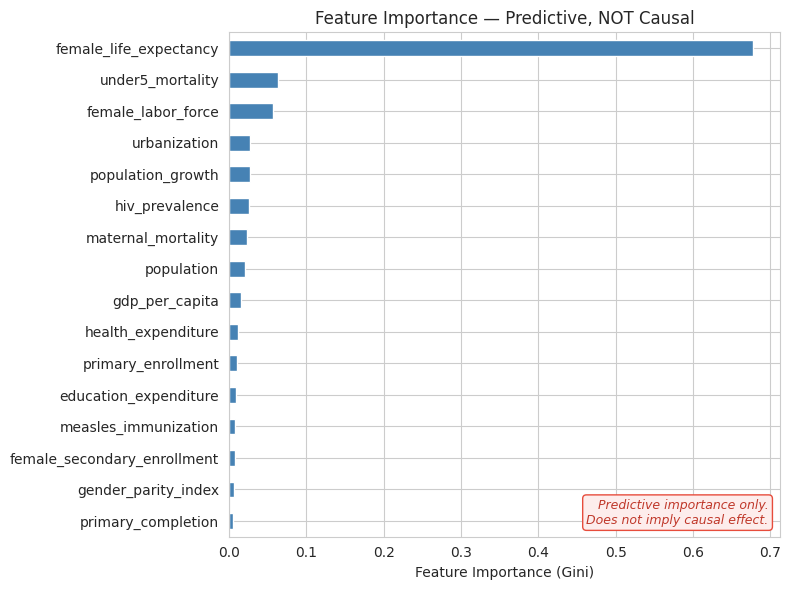

In [17]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# For tree-based models:
importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

# CRITICAL: Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

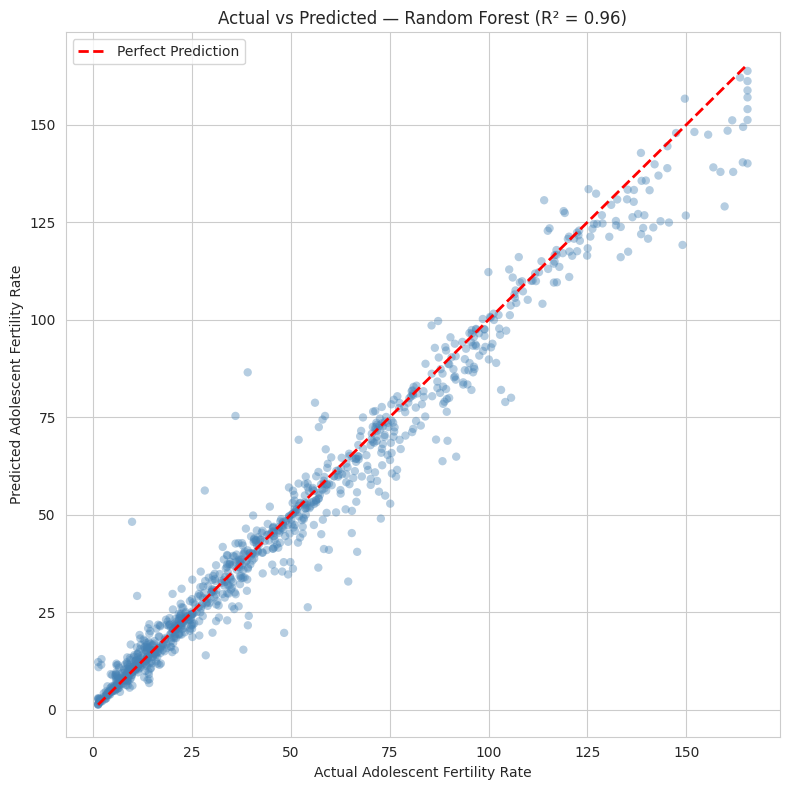

In [18]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_2)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.4, color='steelblue', edgecolors='none')

# Perfect prediction line
min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Adolescent Fertility Rate')
plt.ylabel('Predicted Adolescent Fertility Rate')
plt.title('Actual vs Predicted — Random Forest (R² = 0.96)')
plt.legend()
plt.tight_layout()
plt.show()

**Intepretation:** The plot shows that the Random Forest model predicts adolescent fertility rates closely across the full global range (R² = 0.96). Predictions are tightest at low fertility rates (wealthy countries) and show more spread at mid-to-high rates, suggesting that middle-income and high-fertility countries have more complex and harder to predict.

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** Adolescent pregnancy remains a critical global development challenge affecting millions of girls. Policymakers at international organizations (UNFPA, World Bank, UNICEF) and national governments must decide where to allocate limited resources to most effectively reduce adolescent fertility rates across countries.


**Complication:** If there isn't have a clear data-driven dataframe, the resource will be allocated in measurements and actions after teenager' fertility rate increaseing. However, according to the present analysis, adolescent fertility is driven by a complex, non-linear combination of health, demographic, and socioeconomic factors, rather than only affected by education and income indicators that commonly targeted by policy.


**Resolution:** I recommend prioritizing investments in improving female life expectancy, which is the most important feature according to the feature importance plot. Random Forest model (R² = 0.96) can flag high-risk countries before fertility rates rise, enabling proactive rather than reactive intervention.


**Uncertainty Statement:** Based on our cross-validation results (metric = 0.9575 +/- 0.0039), we estimate that Random Forest model can explain approximately 96% of variance in adolescent fertility rates across countries. The primary limitation is missingness was higher in lower-income countries, meaning predictions for the highest-risk nations may be less reliable. We recommend an early warning screening tool to identify high-risk countries 3–5 years in advance, with the caveat that supplement with lower-income country data before driving resource allocation decisions.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Adolescent Fertility Rate Predictor')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

In [19]:
import joblib
from google.colab import files

joblib.dump(model_2, 'model.pkl')
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Retrain with fewer trees and smaller depth
from sklearn.ensemble import RandomForestRegressor
import joblib

model_small = RandomForestRegressor(
    n_estimators=50,      # reduce from 100
    max_depth=10,         # limit tree depth
    random_state=42
)
model_small.fit(X_train, y_train)

# Check performance is still good
from sklearn.metrics import r2_score
y_pred_small = model_small.predict(X_test)
print(f'R²: {r2_score(y_test, y_pred_small):.4f}')

# Save smaller model
joblib.dump(model_small, 'model_small.pkl', compress=3)  # compress=3 reduces size

# Check file size
import os
size_mb = os.path.getsize('model_small.pkl') / (1024*1024)
print(f'Model size: {size_mb:.1f} MB')

# Download
from google.colab import files
files.download('model_small.pkl')

R²: 0.9294
Model size: 1.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:**
> I collected the dataset from World Bank DataBank and loaded it into Colab. After checking the shape (6,655 rows × 24 columns), I recognized the data was in long format — each row represented a single country-indicator-year observation. This structure is not suitable for ML modeling, which requires one row per country-year with each indicator as a separate column.


**Request:**
> "My current dataset is in long format. To apply this dataset in a Machine Learning project, could you teach me how to reshape it into wide format?"


**Iterate:**
> Claude provided a 4-step reshaping pipeline using pd.melt() to stack year columns, pd.to_numeric() to handle World Bank's .. missing value notation, and pivot_table() to pivot indicators into columns. I ran the code without major modifications and it produced the expected wide format (5,267 rows × 28 columns).


**Mechanism Check:**
> I verified the output by checking df_wide.shape, previewing df_wide.head(), and confirming that each column now represented a distinct indicator and each row represented one country-year observation.


**Evaluate:**
> I accepted the approach because the reshaped format was significantly more readable and directly compatible with scikit-learn's modeling requirements. The logic of each step was clear and I understood what each transformation was doing before proceeding.


---

### AI Interaction 2

**Prep:**
> Following class instructions, I attempted to use wbgapi to fetch 14 indicators across all countries for 30 years in a single API call. The request returned a 524 timeout error because the query volume was too large for the World Bank API to handle at once.


**Request:**
> "Colab shows my request of World Bank is 524 error. I think the workload maybe too large. Could you help me fix the problem?"


**Iterate:**
> Claude suggested fetching one indicator at a time using a loop with a time.sleep(1) pause between requests, then merging all results using functools.reduce. However, even with this approach the API calls were extremely slow and unreliable, taking over 8 minutes without completing.


**Mechanism Check:**
> After waiting over 8 minutes with no output, I concluded the batch API approach was not practical for this project's timeline.


**Evaluate:**
> I rejected this solution and instead returned to World Bank DataBank to manually download all indicators as a single pre-built CSV file. This was a faster and more reliable alternative. Sometimes a simpler manual approach is better than an automated one when working with external APIs.


---

### AI Interaction 3

**Prep:**
> While setting up Model 1 (baseline), I used the professor's starter template which contained LogisticRegression as a placeholder example. Without carefully reading the comment, I ran the cell and received a ValueError because LogisticRegression expects discrete class labels, not continuous values.

**Request:**

> "Could you help me fix this error? I'm getting: ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target."


**Iterate:**
> Claude explained that the root cause was a mismatch between model type and target variable type, LogisticRegression is for classification while my target (adolescent fertility rate) is continuous, requiring a regression model. Claude replaced it with LinearRegression and updated the metrics accordingly to use R², RMSE, and MAE instead of classification_report.


**Mechanism Check:**
> I re-ran the corrected cell and it executed successfully, producing R², RMSE, and MAE scores for Model 1.


**Evaluate:**
> I accepted the fix because it correctly aligned the model type with my problem type (regression). This interaction also reinforced an important concept — always verify that your model class matches your target variable type before running. I applied this understanding independently when setting up Model 2 (Random Forest Regressor).
